# Experiment 3 — Decision Tree Classifier

**Dataset:** Social Network Ads (Kaggle)

**Objective:** Predict whether a user purchases a product based on age and estimated salary.

> Kaggle setup: Add the dataset listed above to the notebook. The code automatically searches `/kaggle/input` for the required files/folders where possible.

In [1]:

import os, glob, warnings
warnings.filterwarnings("ignore")


## 1. Import libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Files available under /kaggle/input:")
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith(".csv"):
            print(os.path.join(root, f))

Files available under /kaggle/input:
/kaggle/input/datasets/shub99/social-network-ads/Social_Network_Ads.csv


## 2. Load the Social Network Ads dataset

In [3]:
paths = glob.glob("/kaggle/input/**/Social_Network_Ads.csv", recursive=True)
if not paths:
    paths = glob.glob("/kaggle/input/**/*.csv", recursive=True)
    paths = [p for p in paths if "social" in p.lower() or "network" in p.lower() or "ads" in p.lower()]
if not paths:
    raise FileNotFoundError("Add the Kaggle Social Network Ads dataset to this notebook.")
path = paths[0]
df = pd.read_csv(path)
print("Loaded:", path)
display(df.head())
print(df.shape)
print(df.isnull().sum())

Loaded: /kaggle/input/datasets/shub99/social-network-ads/Social_Network_Ads.csv


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


(400, 3)
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


## 3. Problem: Predict whether a customer purchases a product from age and estimated salary

In [4]:
# Handle common column-name variants
cols = {c.lower().strip().replace(" ", "_"): c for c in df.columns}
age_col = next((cols[k] for k in cols if k in ["age"]), None)
salary_col = next((cols[k] for k in cols if "salary" in k), None)
target_col = next((cols[k] for k in cols if "purchased" in k or "purchase" in k), None)

if not all([age_col, salary_col, target_col]):
    raise ValueError(f"Could not identify Age/EstimatedSalary/Purchased columns. Found: {list(df.columns)}")

X = df[[age_col, salary_col]]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

model = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 86.25 %

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89        51
           1       0.82      0.79      0.81        29

    accuracy                           0.86        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.86      0.86      0.86        80



## 4. Confusion matrix

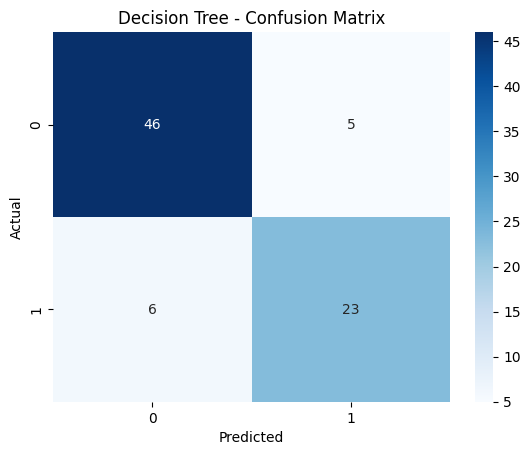

In [5]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

## 5. Visualize the decision tree

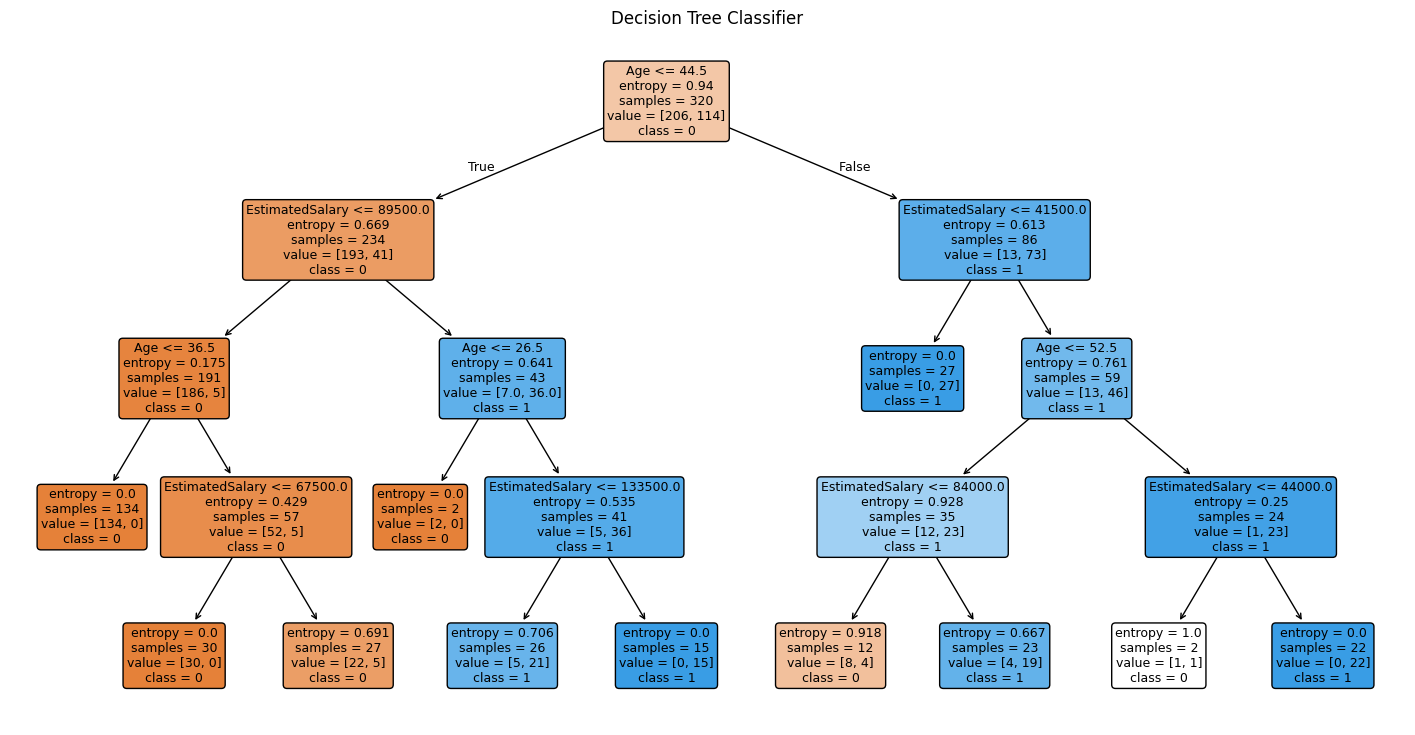

In [6]:
plt.figure(figsize=(18, 9))
plot_tree(model, feature_names=[age_col, salary_col],
          class_names=[str(c) for c in sorted(y.astype(str).unique())],
          filled=True, rounded=True, fontsize=9)
plt.title("Decision Tree Classifier")
plt.show()

## 6. Predict a new customer

In [7]:
new_customer = pd.DataFrame({age_col:[35], salary_col:[60000]})
prediction = model.predict(new_customer)[0]
print("Predicted purchase:", prediction)

Predicted purchase: 0
